In [1]:
import numpy as np
import pandas as pd

### Data Preparation

In [2]:
from sklearn.preprocessing import StandardScaler

pth = r'C:\V\internship_project\CreditcardFraudDetection\data\creditcard.csv'
df  = pd.read_csv(pth)

X = df.drop('Class', axis = 1) # features
y = df['Class'] # labels

print(X.shape)
print(y.shape)


scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# X["Hour"] = (df["Time"] // 3600) % 24 Converting time into periodic signals

X = X.drop('Time', axis = 1)

(284807, 30)
(284807,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size = 0.2, random_state=42, stratify = y # stratify maintains the y ratio in test and train
)

print(X_train.shape)
print(X_test.shape)

(227845, 29)
(56962, 29)


In [4]:
from collections import Counter

train_counts = Counter(y_train)
test_counts = Counter(y_test)

print(train_counts[1]/train_counts[0])
print(test_counts[1]/test_counts[0])

0.0017322412299792043
0.0017234102419808666


**EDA**

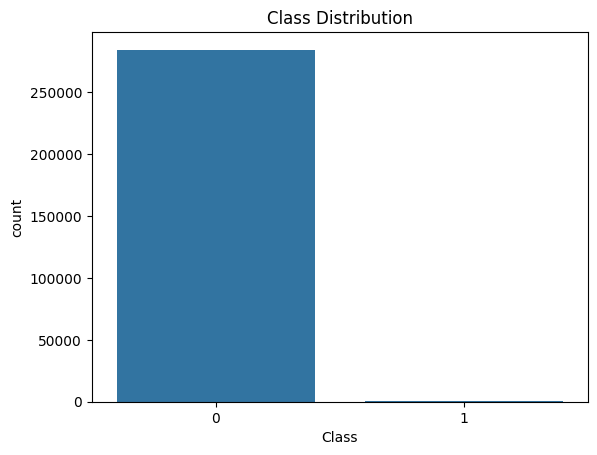

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

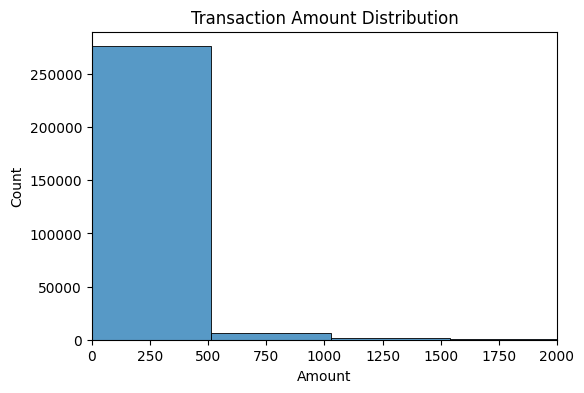

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlim(0,2000)
#plt.ylim(0,100)
plt.show()

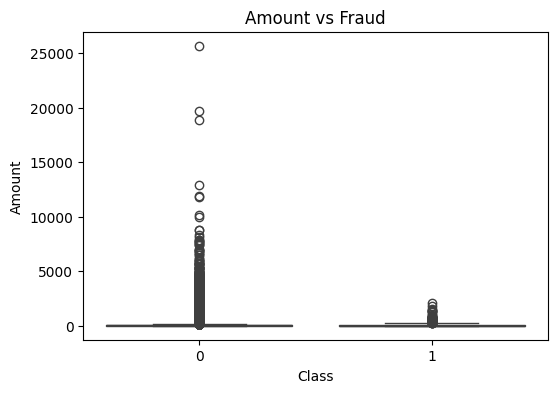

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount vs Fraud")
plt.show()

In [27]:
corr = df.corr()

fraud_corr = corr["Class"].sort_values(ascending=False)

print(fraud_corr)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


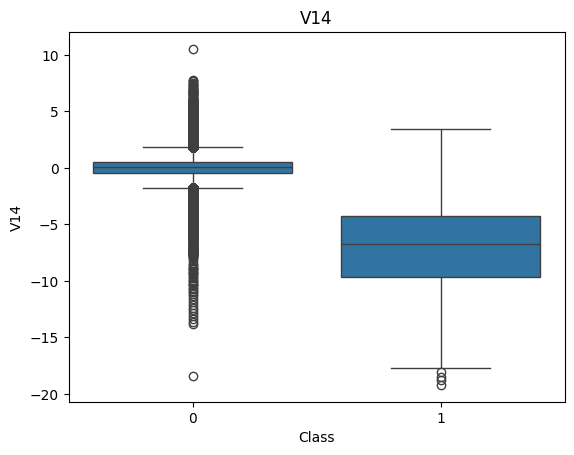

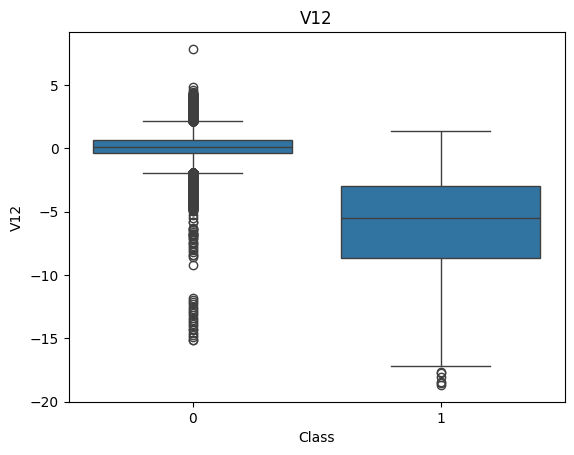

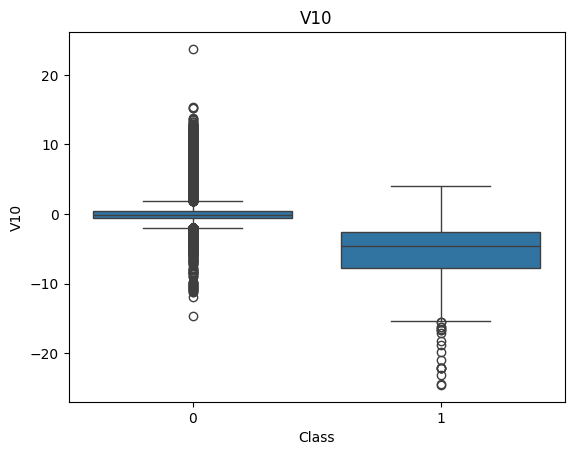

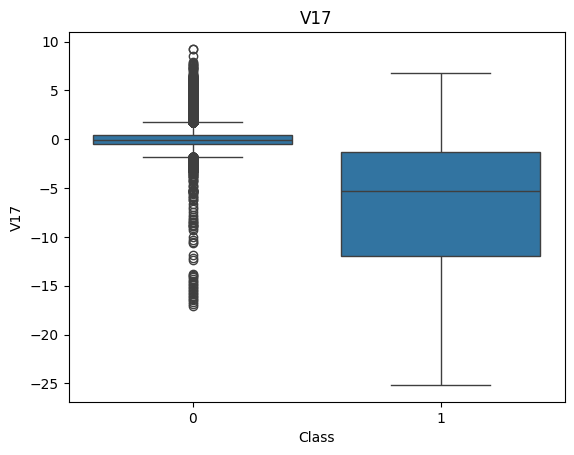

In [28]:
important_features = ["V14", "V12", "V10", "V17"]

for feature in important_features:
    sns.boxplot(x="Class", y=feature, data=df)
    plt.title(feature)
    plt.show()

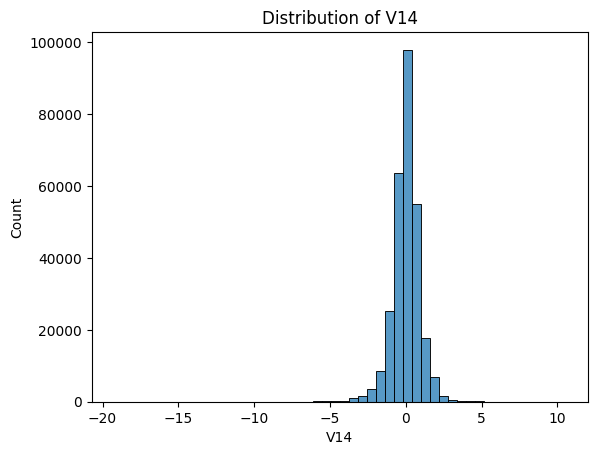

In [29]:
sns.histplot(df["V14"], bins=50)
plt.title("Distribution of V14")
plt.show()

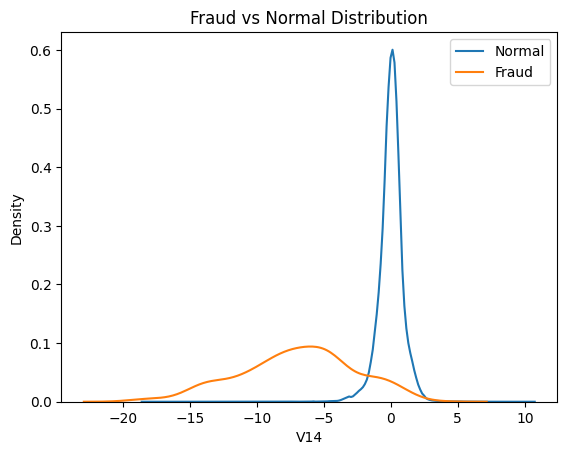

In [30]:
sns.kdeplot(df[df["Class"]==0]["V14"], label="Normal")
sns.kdeplot(df[df["Class"]==1]["V14"], label="Fraud")

plt.legend()
plt.title("Fraud vs Normal Distribution")
plt.show()

### Logistic Regression

**Base Model**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

In [32]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1] # returns [prob_class0 , prob_class1]

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56851    13]
 [   35    63]]


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [35]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_auc)

ROC AUC: 0.9559728259621236


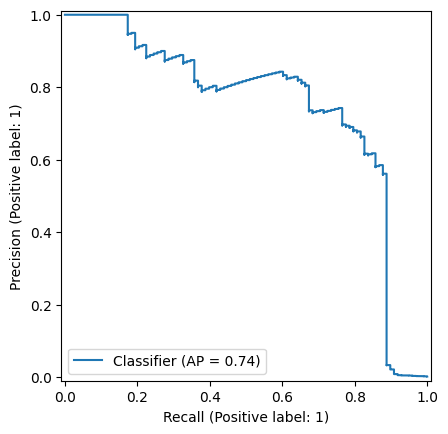

In [38]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob)

In [39]:
import joblib

joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']

### Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators= 80, random_state = 42)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56859     5]
 [   16    82]]


In [24]:
y_prod_rf = rf_model.predict_proba(X_test)[:,1]
y_pred_rf = (y_prod_rf >= 0.425).astype(int)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.86      0.89        98

    accuracy                           1.00     56962
   macro avg       0.96      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [25]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prod_rf)

for i in range(50):
    print(thresholds[i], precision[i], recall[i])

0.0 0.0017204452090867595 1.0
0.0125 0.0653930933137399 0.9081632653061225
0.025 0.2194513715710723 0.8979591836734694
0.0375 0.37130801687763715 0.8979591836734694
0.05 0.5058139534883721 0.8877551020408163
0.0625 0.5620915032679739 0.8775510204081632
0.075 0.6231884057971014 0.8775510204081632
0.0875 0.6666666666666666 0.8775510204081632
0.1 0.6825396825396826 0.8775510204081632
0.125 0.7049180327868853 0.8775510204081632
0.1375 0.7107438016528925 0.8775510204081632
0.15 0.7226890756302521 0.8775510204081632
0.1625 0.7478260869565218 0.8775510204081632
0.175 0.7543859649122807 0.8775510204081632
0.1875 0.7610619469026548 0.8775510204081632
0.2 0.7818181818181819 0.8775510204081632
0.2125 0.8037383177570093 0.8775510204081632
0.2375 0.8113207547169812 0.8775510204081632
0.25 0.8349514563106796 0.8775510204081632
0.2875 0.8514851485148515 0.8775510204081632
0.3 0.8585858585858586 0.8673469387755102
0.325 0.8673469387755102 0.8673469387755102
0.3375 0.8854166666666666 0.8673469387755102

In [47]:
# PR AUC for baseline model predictions
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_rf)
pr_auc = auc(recall, precision)
ap_score = average_precision_score(y_test, y_pred_rf) 
print('Pr_auc base model: ',pr_auc)
print('avg Precision : ' , ap_score)


Pr_auc base model:  0.8902327790533963
avg Precision :  0.7914545690958036


In [26]:
import joblib

joblib.dump(rf_model, 'rf_model_80.pkl')

['rf_model_80.pkl']

### XGBoost

In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators = 1000, learning_rate = 0.01, max_depth = 7)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[56860     4]
 [   18    80]]


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# 1. Define your parameter grid
# We provide a range of values for n_estimators, learning_rate, and max_depth
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'subsample': [0.8, 1.0] # Common to tune this to prevent overfitting
}

# 2. Initialize the base model
xgb_base = XGBClassifier(random_state=42)

# 3. Setup GridSearchCV
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all your CPU cores for faster training
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

# 4. Fit the grid search to your training data
grid_search.fit(X_train, y_train)

# 5. Extract the best model and parameters
print(f"Best Parameters: {grid_search.best_params_}")
best_xgb = grid_search.best_estimator_

# 6. Evaluate on test data
y_pred_best = best_xgb.predict(X_test)

print(confusion_matrix(y_test, y_pred_best))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1000, 'subsample': 0.8}
[[56859     5]
 [   17    81]]


In [61]:
y_pred_best.shape

(56962,)

In [44]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb >= 0.5 ).astype(int)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



**Threshold Tuning**

In [40]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

for i in range(5000, 6000):
    print(thresholds[i], precision[i], recall[i])

3.4670247e-06 0.0019022846827260905 1.0
3.4671768e-06 0.0019023216088205606 1.0
3.4672064e-06 0.0019023585363486363 1.0
3.4678478e-06 0.0019024323957059384 1.0
3.468093e-06 0.0019024693275353315 1.0
3.468331e-06 0.0019025062607986643 1.0
3.4686584e-06 0.0019025431954960202 1.0
3.4693367e-06 0.0019025801316274826 1.0
3.4695715e-06 0.001902617069193135 1.0
3.4696839e-06 0.0019026540081930612 1.0
3.4697734e-06 0.0019026909486273443 1.0
3.4699522e-06 0.0019027278904960683 1.0
3.4699785e-06 0.0019027648337993166 1.0
3.4701009e-06 0.0019028017785371726 1.0
3.4708194e-06 0.00190283872470972 1.0
3.4712762e-06 0.0019028756723170424 1.0
3.4713619e-06 0.0019029126213592233 1.0
3.4714283e-06 0.0019029495718363464 1.0
3.4714383e-06 0.001902986523748495 1.0
3.4715042e-06 0.001903023477095753 1.0
3.4715476e-06 0.001903060431878204 1.0
3.4717164e-06 0.0019030973880959316 1.0
3.4718255e-06 0.0019031343457490194 1.0
3.4720274e-06 0.0019031713048375508 1.0
3.47216e-06 0.0019032452273212794 1.0
3.4729978e

In [48]:
# PR AUC for baseline model predictions
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_xgb)
pr_auc = auc(recall, precision)
ap_score = average_precision_score(y_test, y_pred_xgb) 
print('Pr_auc base model: ',pr_auc)
print('avg Precision : ' , ap_score)


Pr_auc base model:  0.8845117415668209
avg Precision :  0.7777698388187729


In [46]:
import joblib

joblib.dump(xgb_model, 'xgb_mode.pkl')

['xgb_mode.pkl']

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()